# Experiment 4: Data Wrangling and Data Visualization

### Negranza, Jake Andrei D. 
### 2ECE-A  
### September 18, 2026

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
board = pd.read_csv('board2.csv')

# Calculate the Average column if not already present in board2.csv
board['Average'] = board[
        ['Math', 'GEAS', 'Electronics', 'Communication']
    ].mean(axis=1)

### A. Visayas Communication Dataframe

In [23]:
VisComm = board[
    (board['Hometown'] == 'Visayas') & (board['Track'] == 'Communication')
][['Name', 'Gender', 'Math', 'Electronics', 'Average']]

# Display DataFrame and row count
print("--- VisComm DataFrame ---")
print(VisComm)
print(f"\nTotal rows in VisComm: {len(VisComm)}")

--- VisComm DataFrame ---
   Name  Gender  Math  Electronics  Average
10  S11  Female    48           56    54.75
11  S12    Male    89           67    76.00
17  S18    Male    81           40    63.50
21  S22  Female    64           39    62.50
27  S28    Male    85           53    67.75

Total rows in VisComm: 5


### B. Visayas Female Dataframe

In [24]:
# Create VisFemale DataFrame
VisFemale = board[
    (board['Hometown'] == 'Visayas') & (board['Gender'] == 'Female')
][['Name', 'Track', 'GEAS', 'Electronics', 'Average']]

print("--- VisFemale DataFrame ---")
print(VisFemale)

# Filter VisFemale for Average >= 60 without overwriting the original VisFemale
VisFemale_passed = VisFemale[VisFemale['Average'] >= 60]

print("\n--- VisFemale DataFrame (Average >= 60) ---")
print(VisFemale_passed)

--- VisFemale DataFrame ---
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
10  S11     Communication    48           56    54.75
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
23  S24  Microelectronics    60           45    57.75
25  S26   Instrumentation    83           47    65.75

--- VisFemale DataFrame (Average >= 60) ---
   Name             Track  GEAS  Electronics  Average
5    S6  Microelectronics    86           45    75.50
20  S21  Microelectronics    68           51    68.50
21  S22     Communication    89           39    62.50
25  S26   Instrumentation    83           47    65.75


### C. Category-Average Visualization

--- Mean Average by Track ---
              Track  Average
0     Communication   67.975
1   Instrumentation   65.225
2  Microelectronics   67.500

--- Mean Average by Gender ---
   Gender    Average
0  Female  66.616667
1    Male  67.183333

--- Mean Average by Hometown ---
   Hometown    Average
0     Luzon  68.083333
1  Mindanao  66.678571
2   Visayas  65.750000


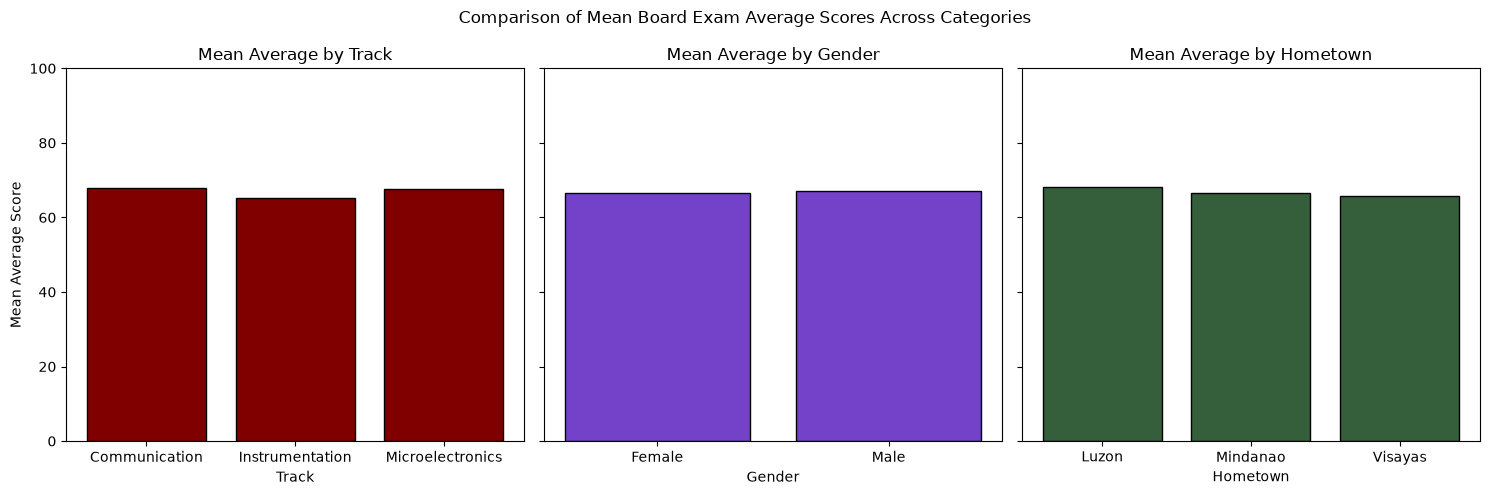

In [25]:
# --- a & b: Compute means and display summary tables ---
track_summary = board.groupby('Track')['Average'].mean().reset_index()
gender_summary = board.groupby('Gender')['Average'].mean().reset_index()
hometown_summary = board.groupby('Hometown')['Average'].mean().reset_index()

print("--- Mean Average by Track ---")
print(track_summary)
print("\n--- Mean Average by Gender ---")
print(gender_summary)
print("\n--- Mean Average by Hometown ---")
print(hometown_summary)

# --- c: Create one figure with three bar charts ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
colors = ['#800000', '#7442C8', '#355E3B']

# Track Chart
axes[0].bar(
    track_summary['Track'],
    track_summary['Average'],
    color=colors[0],
    edgecolor='black',
)
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average Score')
axes[0].set_ylim(0, 100)

# Gender Chart
axes[1].bar(
    gender_summary['Gender'],
    gender_summary['Average'],
    color=colors[1],
    edgecolor='black',
)
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')

# Hometown Chart
axes[2].bar(
    hometown_summary['Hometown'],
    hometown_summary['Average'],
    color=colors[2],
    edgecolor='black',
)
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')

plt.suptitle('Comparison of Mean Board Exam Average Scores Across Categories')
plt.tight_layout()
plt.show()

### Interpretation Statements

1. **Track:** Among the specialization tracks, the **Communication** track recorded the highest sample mean board-exam score at approximately **67.98**.
2. **Gender:** Between the gender categories, **Male** students recorded the highest sample mean board-exam score at approximately **67.18**.
3. **Hometown:** Among the regional hometown groups, students from **Luzon** recorded the highest sample mean board-exam score at approximately **68.08**.
